In [5]:
# Imports
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import scipy.optimize as curve_fit

In [99]:
current_directory = Path.cwd().parent
compiled_file_name = Path.joinpath(current_directory, "final_cleaned_compiled (with SoC).csv")
points_of_interest_file_name = Path.joinpath(current_directory, "points_of_interest.json")
RC_values_file_name = Path.joinpath(current_directory, "RC_values.csv")
ocv_soc_dict_file_name = Path.joinpath(current_directory, "ocv_soc_dict.json")

In [100]:
points_of_interest = json.load(open(points_of_interest_file_name, 'r'))

In [101]:
compiled_df = pd.read_csv(compiled_file_name)

In [9]:
before_open = points_of_interest['before_open']
before_close = points_of_interest['before_close']

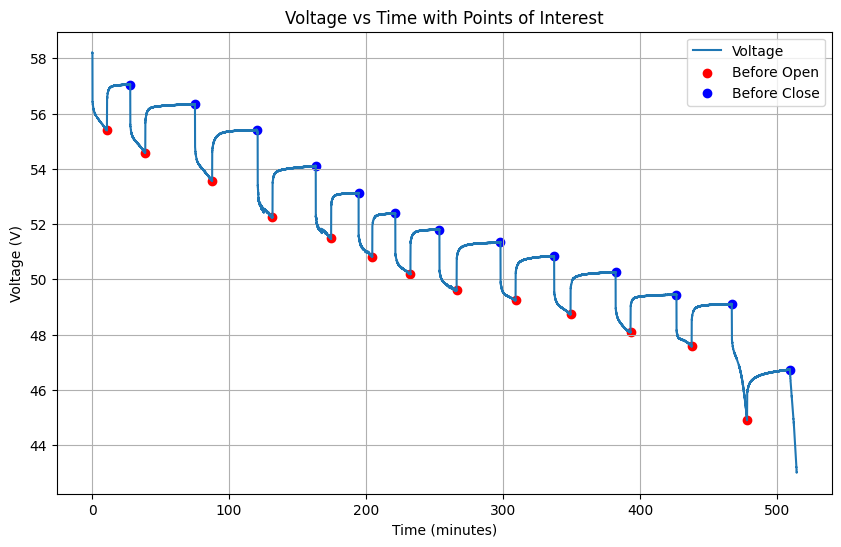

In [102]:
plt.figure(figsize=(10, 6))
plt.plot(compiled_df['Translated Time (minutes)'], compiled_df['Calibrated Voltage'], label='Voltage')
plt.scatter(before_open['time'], before_open['voltage'], color='red', label='Before Open')
plt.scatter(before_close['time'], before_close['voltage'], color='blue', label='Before Close')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time with Points of Interest')
plt.legend()
plt.grid()
plt.show()

In [103]:
if before_close['time'][0] < before_open['time'][0]:
    before_close['time'] = before_close['time'][1:]
    before_close['voltage'] = before_close['voltage'][1:]
    before_close['index'] = before_close['index'][1:]
    print("Dropped first point from before_close.")

In [104]:
# V(t) = OCV - A1 * e^(-t / tau1) - A2 * e^(-t / tau2)
def two_rc_model(t, OCV, A1, tau1, A2, tau2):
    return OCV - A1 * np.exp(-t / tau1) - A2 * np.exp(-t / tau2)

def curve_fit_bound(ocv, v_0_before_switch):
    # [ocv, A1, tau1, A2, tau2]
    lower = [
        ocv - 0.5,  # Cannot be less than 500mV below OCV
        0.001, 1,   # Must be positive
        0.001, 1
        ]
    
    total_swing = ocv - v_0_before_switch

    # Upper bound time constant is set arbitrarily
    # but tau2 > tau1
    upper = [
        ocv + 0.5,  # Cannot be more than 500mV above OCV
        total_swing, 150,   # Fast RC
        total_swing, 2000   # slow RC
        ]
    return (lower, upper)

def initial_guess(ocv, v_0_before_switch):
    A1_guess = (ocv - v_0_before_switch) * 0.8  # Initial guess for A1 based on voltage drop
    A2_guess = 0.5 * A1_guess  # Assume the second RC contributes less
    tau1_guess = 50  # Fast RC time constant guess
    tau2_guess = 500  # Slow RC time constant guess

    return [ocv, A1_guess, tau1_guess, A2_guess, tau2_guess]

In [ ]:
def extract_last_stable_current(compiled_df, start_index):
    STEP_SIZE = 20
    threshold = 0.5
    df = compiled_df[max(0, start_index - STEP_SIZE): start_index]  # Look back up to 20 rows
    median_current = df['Calibrated Current 1'].median()
    
    index_at_stable = start_index
    total = []
    
    for i in range(start_index, max(0, start_index - STEP_SIZE), -1):
        diff = abs((compiled_df['Calibrated Current 1'][i] + compiled_df['Calibrated Current 2'][i]) / 2 - median_current)
        if diff < threshold:
            total.append((compiled_df['Calibrated Current 1'][i]  + compiled_df['Calibrated Current 2'][i]) / 2)
            index_at_stable = i if index_at_stable == start_index else index_at_stable
            
    return sum(total) / len(total) if total else 0, index_at_stable 

In [123]:
fitted_params_list = {
    "SoC": [],
    "OCV": [],
    "r0": [],
    "A1": [],
    "tau1": [],
    "r1": [],
    "c1": [],
    "A2": [],
    "tau2": [],
    "r2": [],
    "c2": []
}

if len(before_open['time']) != len(before_close['time']):
    print("Warning: before_open and before_close have different lengths.")
else:
    for i in range(len(before_open['time'])):
        rest_interval = (before_open['index'][i], before_close['index'][i])

        # Start fitting once the current reading is 0
        found_zero_current = False
        for j in range(rest_interval[0], rest_interval[1]):
            if compiled_df['Calibrated Current 1'][j] < 1:
                found_zero_current = True
                break
        if not found_zero_current:
            print(f"Warning: No zero current point found between indices {rest_interval[0]} and {rest_interval[1]}. Skipping this interval.")
            continue
        
        start_index = j
        
        df_interval = compiled_df.iloc[start_index:rest_interval[1]]
        time_data_s = (df_interval['Translated Time (minutes)'] - df_interval['Translated Time (minutes)'].iloc[0]) * 60  # Reset time to start at 0
        voltage_data = df_interval['Calibrated Voltage']
        ocv = before_close['voltage'][i]
        before_open_voltage = before_open['voltage'][i]
        params, cov = curve_fit.curve_fit(two_rc_model, time_data_s, voltage_data, 
                                          p0=initial_guess(ocv, before_open_voltage), 
                                          bounds=curve_fit_bound(ocv, before_open_voltage))
        
        OCV_fit, A1_fit, tau1_fit, A2_fit, tau2_fit = params
        print(f"Interval {i}: OCV={OCV_fit:.3f} V, A1={A1_fit:.3f} V, tau1={tau1_fit:.2f} s, A2={A2_fit:.3f} V, tau2={tau2_fit:.2f} s")
        print(f"Function: V(t) = {OCV_fit:.3f} - {A1_fit:.3f} * np.exp(-t / {tau1_fit:.2f}) - {A2_fit:.3f} * np.exp(-t / {tau2_fit:.2f})")
        
        # Fitting evaluation
        v_fitted = two_rc_model(time_data_s, *params)
        residuals = voltage_data - v_fitted
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((voltage_data - np.mean(voltage_data))**2)
        r_squared = 1 - (ss_res / ss_tot)
        print(f"R-squared: {r_squared:.4f}")
        
        # Extract RC values
        I_before, stable_index = extract_last_stable_current(compiled_df, start_index)

        R1 = A1_fit / I_before  if I_before != 0 else np.inf
        C1 = tau1_fit / R1      if R1 != np.inf else np.inf
        R2 = A2_fit / I_before  if I_before != 0 else np.inf
        C2 = tau2_fit / R2      if R2 != np.inf else np.inf
        
        V_after = two_rc_model(0, *params)  # Voltage at t=0
        V_before = compiled_df['Calibrated Voltage'][stable_index-10:stable_index].mean()  # Average voltage before switch
        R0 = abs(V_before - V_after) / I_before if I_before != 0 else np.inf
        
        # Store fitted parameters
        fitted_params_list["OCV"].append(OCV_fit)
        fitted_params_list["r0"].append(R0)
        fitted_params_list["A1"].append(A1_fit)
        fitted_params_list["r1"].append(R1)
        fitted_params_list["c1"].append(C1)
        fitted_params_list["A2"].append(A2_fit)
        fitted_params_list["r2"].append(R2)
        fitted_params_list["c2"].append(C2)
        fitted_params_list["SoC"].append(compiled_df['SoC'].iloc[stable_index])
        fitted_params_list["tau1"].append(tau1_fit)
        fitted_params_list["tau2"].append(tau2_fit)
        
        print(f"RC values: R0={R0:.5f} Ohm, R1={R1:.5f} Ohm, C1={C1:.5f} F, R2={R2:.5f} Ohm, C2={C2:.5f} F\n")     
        

Interval 0: OCV=57.052 V, A1=0.393 V, tau1=43.12 s, A2=0.154 V, tau2=266.07 s
Function: V(t) = 57.052 - 0.393 * np.exp(-t / 43.12) - 0.154 * np.exp(-t / 266.07)
R-squared: 0.9978
RC values: R0=0.03977 Ohm, R1=0.01413 Ohm, C1=3051.90001 F, R2=0.00555 Ohm, C2=47911.81127 F

Interval 1: OCV=56.336 V, A1=0.514 V, tau1=53.84 s, A2=0.183 V, tau2=643.19 s
Function: V(t) = 56.336 - 0.514 * np.exp(-t / 53.84) - 0.183 * np.exp(-t / 643.19)
R-squared: 0.9977
RC values: R0=0.03963 Ohm, R1=0.01929 Ohm, C1=2791.54416 F, R2=0.00685 Ohm, C2=93833.93493 F

Interval 2: OCV=55.400 V, A1=0.440 V, tau1=60.82 s, A2=0.367 V, tau2=356.81 s
Function: V(t) = 55.400 - 0.440 * np.exp(-t / 60.82) - 0.367 * np.exp(-t / 356.81)
R-squared: 0.9981
RC values: R0=0.03873 Ohm, R1=0.01662 Ohm, C1=3659.60714 F, R2=0.01388 Ohm, C2=25700.54681 F

Interval 3: OCV=54.143 V, A1=0.390 V, tau1=59.46 s, A2=0.269 V, tau2=1050.83 s
Function: V(t) = 54.143 - 0.390 * np.exp(-t / 59.46) - 0.269 * np.exp(-t / 1050.83)
R-squared: 0.9981


In [124]:
print(json.dumps(fitted_params_list, indent=4))

{
    "SoC": [
        92.18063458961844,
        84.75269726062035,
        76.20773113629188,
        68.52003283175685,
        61.01682431874281,
        54.53108630832465,
        47.5068865758427,
        39.58139052016432,
        32.10415662765692,
        24.45018787995342,
        17.40561822734498,
        10.33513168509857,
        3.418120059631641
    ],
    "OCV": [
        57.05195902672817,
        56.33636627850599,
        55.40025647711651,
        54.14272739085175,
        53.12550851550196,
        52.385488477855866,
        51.800179860480235,
        51.330783782756846,
        50.8513105360166,
        50.258650373163164,
        49.44837297902921,
        49.10472184254794,
        46.7731795319974
    ],
    "r0": [
        0.03976901690288419,
        0.03962526729487737,
        0.03872664174521806,
        0.04630391230449637,
        0.04528534002577369,
        0.042332682298017954,
        0.04362708398286041,
        0.045802355319456825,
        0.0

In [131]:
normalised_soc = np.array(fitted_params_list["SoC"]) - 50

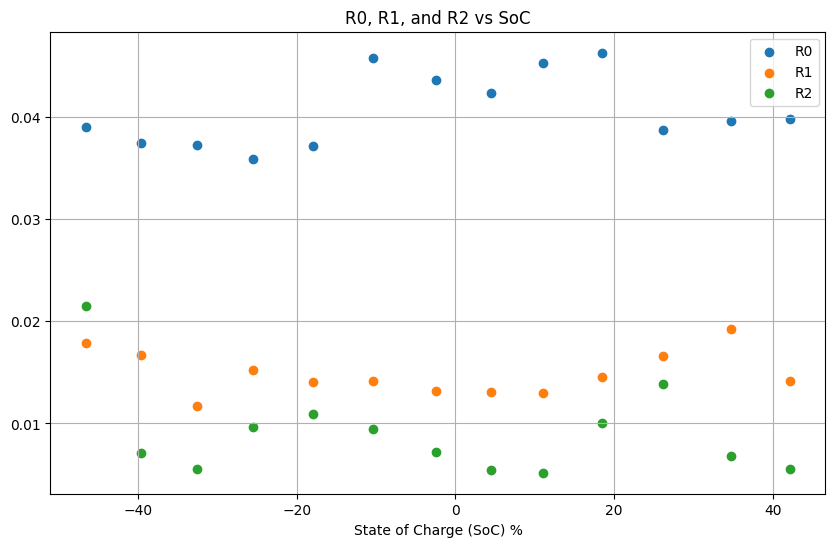

In [132]:
plt.figure(figsize=(10, 6))
plt.scatter(normalised_soc, fitted_params_list["r0"])
plt.scatter(normalised_soc, fitted_params_list["r1"])
plt.scatter(normalised_soc, fitted_params_list["r2"])
plt.title('R0, R1, and R2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend(['R0', 'R1', 'R2'])
plt.grid()
plt.show()


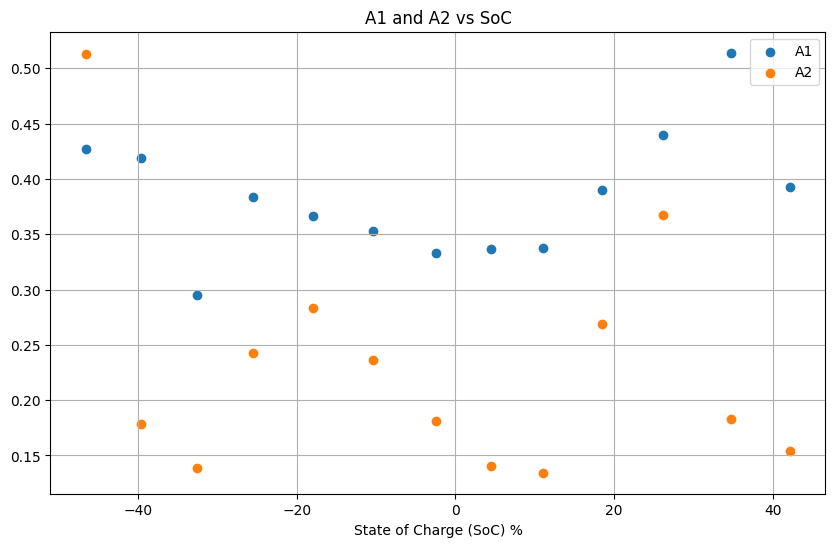

In [133]:
plt.figure(figsize=(10, 6))
plt.scatter(normalised_soc, fitted_params_list["A1"])
plt.scatter(normalised_soc, fitted_params_list["A2"])
plt.title('A1 and A2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend(['A1', 'A2'])
plt.grid()
plt.show()


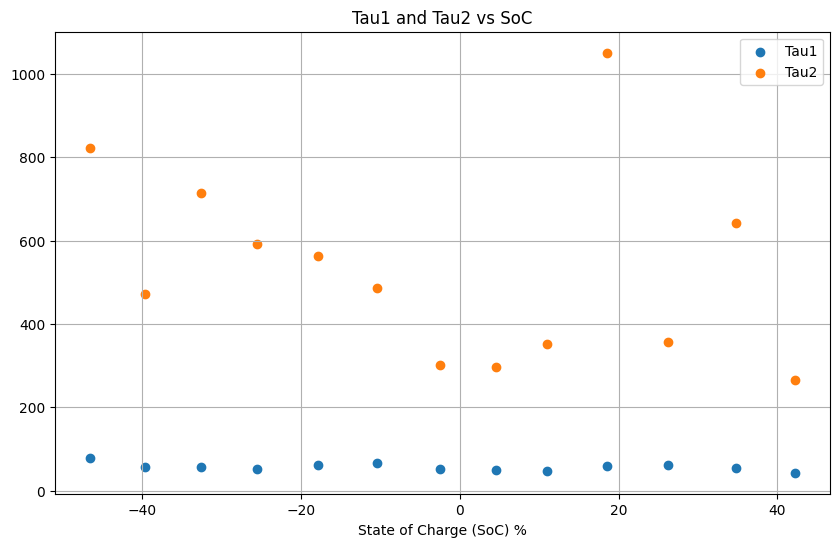

In [134]:
plt.figure(figsize=(10, 6))
plt.scatter(normalised_soc, fitted_params_list["tau1"])
plt.scatter(normalised_soc, fitted_params_list["tau2"])
plt.title('Tau1 and Tau2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend(['Tau1', 'Tau2'])
plt.grid()
plt.show()


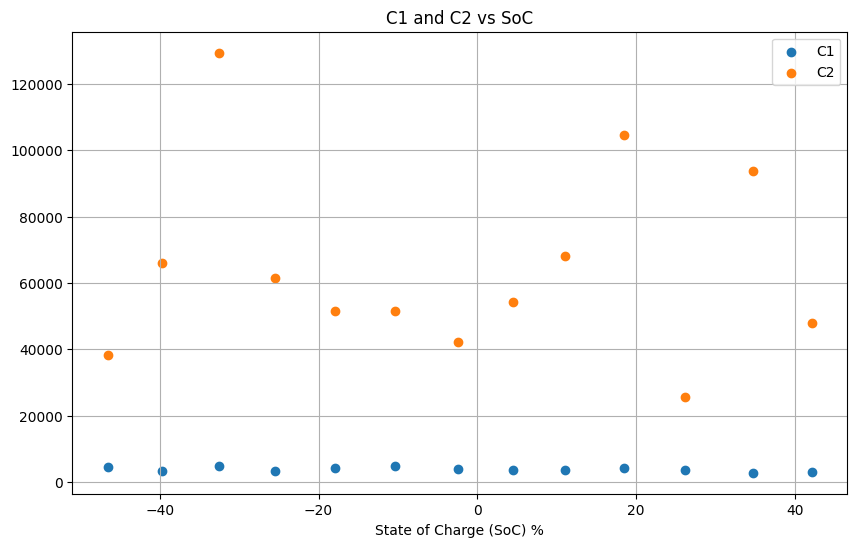

In [135]:
plt.figure(figsize=(10, 6))
plt.scatter(normalised_soc, fitted_params_list["c1"])
plt.scatter(normalised_soc, fitted_params_list["c2"])
plt.title('C1 and C2 vs SoC')
plt.xlabel('State of Charge (SoC) %')
plt.legend(['C1', 'C2'])
plt.grid()
plt.show()
